# 2. Landmark EKF

Your task is to implement an Landmark-EKF SLAM system and analyse the resulting state estimate.

We have provided a Simulator and key visualisation functions for you to use. Please study the provided code closely.

### State transition and observation models
Implement the `utils.motion_model`, `utils.inverse_sensor_model` and `utils.sensor_model` functions. These will be useful to implement the EKF and include content taken directly from the lectures.

The motion model should implement $x_k = f(x_{k_1}, u_{k-1})$ as well as the Jacobians $G_1 = \frac{\partial f}{\partial x}$ and $G_2 = \frac{\partial f}{\partial u}$.

The sensor model should implement $z_i = h(x_k, l_i)$ as well as the Jacobians  $H_1 = \frac{\partial h}{\partial x}$ and $H_2 = \frac{\partial h}{\partial l}$.

>> NOTE: the simulation will not run until you have implemented `utils.motion_model` as this is needed to generate robot odometry.

### Implement the EKF
We have provided a simulator that generates robot odometry and landmark measurements. You need to implement the `predict` and `update` functions in the EKF.

We have provided visualisation functions that will enable your estimated pose and map to be visualised as an animation. This function takes many arguments to show the estimated/ground truth trajectory as well as the estimated landmarks. See the keyword arguments in `visualize_slam_animation` or uncomment the various arguments in `main`.

We also provide a simple `visualize_errors` function that visualises a scalar error. When it comes to quantifying the accuracy of your filter uncomment or modify this function to show per-timestep error.

In [1]:
# %matplotlib notebook

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import matplotlib
from copy import deepcopy

from typing import List
import os
import pickle

In [2]:

def pi2pi(angle):
    """
    Maps angle to the range of [-pi, pi]
    :param angle: then angle that needs to be mapped to the range [-pi, pi]
    :return : angle in the range [-pi, pi]
    """
    dp = 2*np.pi
    if angle <= -dp or angle >= dp:
        angle = angle % dp
    if angle >= np.pi:
        angle = angle - dp
    if angle <= -np.pi:
        angle = angle + dp
    return angle

class utils:
    @staticmethod
    def motion_model(pose, motion_command):
        """
        Implement the non-linear state-transition function x_k = f(x_{k-1}, u_{k-1})
        which returns x_k and Jacobians H1, H2

        Args:
            pose (_type_): x_{k-1}
            motion_command (_type_):  u_{k-1}

        Returns:
            _type_: new poses and Jacobians df\dx and df\du
        """
        x1, y1, theta1 = pose.flatten()
        dx, dy, dtheta = motion_command.flatten()

        u_rel = motion_command.reshape((3,1))

        R = np.array([[np.cos(theta1), -np.sin(theta1), 0],
            [np.sin(theta1), np.cos(theta1), 0],
            [0, 0, 1]])

        next_robot_pose_abs = R @ u_rel + pose
        # next_robot_pose_abs[2][0] = pi2pi(next_robot_pose_abs[2][0])

        # Calculate Jacobian of X_t+1 with respect to the current robot pose X_t
        F = np.array([[1, 0, -dx*np.sin(theta1)-dy*np.cos(theta1)],
            [0, 1,  dx*np.cos(theta1)-dy*np.sin(theta1)],
            [0, 0, 1]])

        # Calculate Jacobian of X_t+1 with respect to motion command u
        W = np.array([[np.cos(theta1), -np.sin(theta1), 0],
            [np.sin(theta1), np.cos(theta1), 0],
            [0, 0, 1]])

        assert(next_robot_pose_abs.shape == (3,1)), next_robot_pose_abs.shape

        return next_robot_pose_abs, F, W

    @staticmethod
    def inverse_sensor_model(pose, relative_xy):
        """
        Implement the inverse of the sensor model g(x) where, given a relative sensor measurement and pose
        calculate the expected landmark location in the global frame.

        Pose will be an array [x,y,theta] and relative_xy is the [x,y] relative measurements of the landmark.

        Args:
            pose (_type_): np.array (3,1)
            relative_xy (_type_): np.array (2,1)

        Returns:
            _type_: Absolute landmark location and Jacobians df\dx df\dl
        """
        _, _, theta1 = pose.flatten()
        x2, y2 = relative_xy

        landmark_position_rel_vec = np.array([[x2], [y2], [1]])

        # R is the transition matrix to robot frame
        R = np.array([[np.cos(theta1), -np.sin(theta1), 0],
            [np.sin(theta1), np.cos(theta1), 0],
            [0, 0, 1]])

        # Calculate Jacobian G1 with respect to X1
        G1 = np.array([[1, 0, -x2*np.sin(theta1)-y2*np.cos(theta1)],
            [0, 1,  x2*np.cos(theta1)-y2*np.sin(theta1)]])

        # Calculate Jacobian G2 with respect to X2
        G2 = np.array([[np.cos(theta1), -np.sin(theta1)],
            [np.sin(theta1),  np.cos(theta1)]])

        landmark_abs = np.array(np.dot(R, landmark_position_rel_vec)) + np.array(pose)

        return np.array([[landmark_abs[0][0]], [landmark_abs[1][0]]]), G1, G2



        # return absolute_xy, H1, H2

    @staticmethod
    def sensor_model(pose, absolute_xy):
        """
            Implement sensor model h(x) where, given a absolute sensor measurement and pose
            calculate the expected landmark location in the local frame.

            This is used to calculate the expected measurement (in the local frame) given the current estimate
            of the robot and landmark

            Pose will be an array [x,y,theta] and absolute_xy is the [x,y] relative measurements of the landmark.

            Args:
                pose (_type_): np.array (3,1)
                absolute_xy (_type_): np.array (2,1)

            Returns:
                _type_: relative landmark location and Jacobians df\dx df\dl
        """
        x1, y1, theta1 = pose.flatten()
        x2, y2 = absolute_xy

        diff = np.array([[x2-x1],
            [y2-y1],
            [1]])

        # R is the transition matrix to robot frame
        R = [[np.cos(-theta1), -np.sin(-theta1), 0],
            [np.sin(-theta1), np.cos(-theta1), 0],
            [0, 0, 1]]

        landmark_position_rel = np.dot(R, diff)

        # Calculate Jacobian of the relative landmark position wrt. the robot pose,
        # i.e. [x1, y1, theta1]
        H = np.array([[-np.cos(theta1), -np.sin(theta1), -(x2-x1)*np.sin(theta1)+(y2-y1)*np.cos(theta1)],
            [np.sin(theta1), -np.cos(theta1), -(x2-x1)*np.cos(theta1)-(y2-y1)*np.sin(theta1)]])

        # Calculate Jacobian of the relative landmark position wrt. the absolute
        # landmark pose. i.e. [x2, y2]
        J = np.array([[np.cos(theta1), np.sin(theta1)],
            [-np.sin(theta1), np.cos(theta1)]])

        return np.array([[landmark_position_rel[0][0]], [landmark_position_rel[1][0]]]), H, J

In [3]:
class LandmarkMeasurement:
    def __init__(self, label, x, y, covariance):
        self.label = label
        self.x = x
        self.y = y
        self.covariance = covariance

class ControlMeasurement:
    def __init__(self, motion_vector, covariance):
        self.motion_vector = motion_vector
        self.covariance = covariance

class se2:

    def __init__(self, x: float = None, y: float = None, theta: float = None, data=None):
        """Initialize SE(2) transform with either:
        - explicit x, y, theta (radians), or
        - a list/array [x, y, theta].
        """
        if data is not None:
            if isinstance(data, np.ndarray):
                data = list(data.flatten())
            if isinstance(data, list) and len(data) == 3:
                self.x, self.y, self.theta = data
                assert isinstance(self.x, float), f"x is of type {type(self.x)}, {self.x}"
                assert isinstance(self.y, float), f"y is of type {type(self.y)}"
                assert isinstance(self.theta, float), f"theta is of type {type(self.theta)}"
            else:
                raise ValueError("data must be a list or array of length 3.")
        elif x is not None and y is not None and theta is not None:
            self.x = x
            self.y = y
            self.theta = theta
        else:
            raise ValueError("Provide either (x, y, theta) or a list/array of size 3.")
        # store cos(theta)
        self._c = np.cos(self.theta)
        # store sin(theta)
        self._s = np.sin(self.theta)

    def matrix(self):
        return np.array([
            [self._c, -self._s, self.x],
            [self._s,  self._c, self.y],
            [0,  0, 1]
        ])

    def compose(self, other):
        """Compose this transform with another SE(2) transform."""
        result_matrix = self.matrix() @ other.matrix()
        x, y = result_matrix[:2, 2]
        theta = np.arctan2(result_matrix[1, 0], result_matrix[0, 0])
        return se2(x, y, theta)

    def inverse(self):
        """Compute the inverse of this transform."""
        inv_x = -self._c * self.x - self._s * self.y
        inv_y =  self._s * self.x - self._c * self.y
        return se2(inv_x, inv_y, -self.theta)

    def __mul__(self, other: "se2") -> "se2":
        """Overload the multiplication operator for composition."""
        return self.compose(other)


In [4]:
class ExtendedKalmanFilter(object):

    def __init__(self) -> None:
        self._state_vector = np.array([[0.0], [0.0], [0.0]])

        sigma_position = np.sqrt(10.0 ** -3)
        sigma_orientation = np.sqrt(10.0 ** -3)
        self._state_covariance = np.array(
          [
            [sigma_position ** 2, 0., 0.],
            [0., sigma_position ** 2, 0.],
            [0., 0., sigma_orientation ** 2]
          ]
        )
        self._landmark_index = {}

    @property
    def x(self):
        return deepcopy(self._state_vector[0])

    @property
    def y(self):
        return deepcopy(self._state_vector[1])

    @property
    def yaw(self):
        return deepcopy(self._state_vector[2])

    @property
    def pose(self):
        return np.array([self.x, self.y, self.yaw], copy=True)

    @property
    def pose_covariance(self):
        return np.array(self._state_covariance[0:3, 0:3], copy=True)

    @property
    def state_mean(self):
        return np.array(self._state_vector, copy=True)

    @property
    def num_landmarks(self):
        landmark_poses = self.state_mean[3:]
        return int(len(landmark_poses)/2)


    @property
    def landmarks(self):
        landmark_array = [self.landmark(label) for label in self._landmark_index.keys()]
        if len(landmark_array) == 0:
            return np.array([])
        return np.stack(landmark_array)


    def landmark(self, label):
        return self.extract_landmark_from_state(label, self.state_mean)

    def pose_as_se2(self) -> se2:
        x,y,theta = self.pose.flatten()
        return se2(x, y, theta)

    def extract_landmark_from_state(self, label, state_mean):
        if label not in self._landmark_index:
            return None

        state_index = self._landmark_index[label]
        return np.array([state_mean[state_index][0], state_mean[state_index+1][0]])


    @property
    def state_covariance(self):
        return np.array(self._state_covariance, copy=True)

    def predict(self, control_meaurement: ControlMeasurement):
        motion_command = control_meaurement.motion_vector
        motion_covariance = control_meaurement.covariance
        pose = self._state_vector[0:3]
        predicted_robot_pose, F, W = utils.motion_model(pose, motion_command)
        np.copyto(self._state_vector[0:3], predicted_robot_pose)

        # Update robot-robot covariance block
        P_rr = self._state_covariance[0:3, 0:3]
        self._state_covariance[0:3, 0:3] = F @ P_rr @ F.T + W @ motion_covariance @ W.T

        # Update robot-landmark cross-covariance blocks (F_aug applied to full P)
        n = self._state_covariance.shape[0]
        if n > 3:
            P_rl = self._state_covariance[0:3, 3:]
            self._state_covariance[0:3, 3:] = F @ P_rl
            self._state_covariance[3:, 0:3] = (F @ P_rl).T


    def update(self, landmark_measurements: List[LandmarkMeasurement]):
        if len(landmark_measurements) == 0:
            return

        pose = self.pose
        state_covariance = self.state_covariance
        x = self.state_mean  # Prior state mean

        C_list = []
        Z_list = []
        expected_measurements_list = []
        R_list = []

        # construct and update size of state cov if new landmarks needed
        for landmark_measurement in landmark_measurements:
            label = landmark_measurement.label

            if label not in self._landmark_index:
                print(f"Gotten new landmark {landmark_measurement.label}")
                # New landmark detected
                landmark_measured_abs, H1, H2 = utils.inverse_sensor_model(pose, [landmark_measurement.x, landmark_measurement.y])

                index = x.shape[0]
                print(f"Insertion index {index}")
                self._landmark_index[label] = index
                x = np.vstack((x, landmark_measured_abs))

                Prr = self.pose_covariance
                if len(self._landmark_index) == 1:
                    Plx = np.dot(H1, Prr)
                else:
                    last_state_covariance = deepcopy(state_covariance)
                    Prm = last_state_covariance[0:3, 3:]
                    Plx = np.dot(H1, np.bmat([[Prr, Prm]]))

                Pll = np.dot(H1, np.dot(Prr, H1.T)) + np.dot(H2, np.dot(landmark_measurement.covariance, H2.T))

                P = np.bmat([[state_covariance, Plx.T], [Plx, Pll]])
                state_covariance = np.array(P, copy=True)


        for landmark_measurement in landmark_measurements:
            label = landmark_measurement.label
            estimated_landmark = self.extract_landmark_from_state(label, x)
            expected_measurement, Hr, Hl = utils.sensor_model(pose, estimated_landmark)

            Z_list.append(np.array([[landmark_measurement.x], [landmark_measurement.y]]))
            expected_measurements_list.append(expected_measurement)
            R_list.append(landmark_measurement.covariance)

            # Construct the C matrix
            index = self._landmark_index[label]

            C_cols = state_covariance.shape[0]
            C = np.zeros((2, C_cols))
            C[:, :3] = Hr

            # add Hl at correct index
            C[:, index:index+2] = Hl
            C_list.append(C)


        # Stack all measurements and Jacobians
        C = np.vstack(C_list)
        Z = np.vstack(Z_list)

        R = ExtendedKalmanFilter.block_diag(R_list)

        expected_measurements = np.vstack(expected_measurements_list)

        y = Z - expected_measurements  # Innovation term
        S = C @ state_covariance @ C.T + R

        if np.linalg.det(S) < 1e-6:
            # print(f'WARNING!!! Non-invertible S Matrix {np.linalg.det(S)}')
            # hack by adding reguarlisaer
            S = ExtendedKalmanFilter.reguarlise_matrix(S)

        K = state_covariance @ C.T @ np.linalg.inv(S)
        posterior_state_mean = x + K @ y
        I = np.eye(len(posterior_state_mean))
        posterior_state_covariance = (I - K @ C) @ state_covariance

        # Update state
        # np.copyto(self._state_vector, posterior_state_mean)
        self._state_vector = np.array(posterior_state_mean, copy=True)
        self._state_covariance = np.array(posterior_state_covariance, copy=True)

    @staticmethod
    def reguarlise_matrix(S, l=0.1):
        assert S.shape[0] == S.shape[1], "Matrix S must be square."

        # Create an identity matrix of the same size as S
        I = np.eye(S.shape[0])

        # Apply L2 regularization (add lambda * I)
        S_reg = S + l * I

        # Check if S_reg is invertible by computing its determinant
        if np.linalg.det(S_reg) == 0:
            raise ValueError("The regularized matrix is still singular.")

        return S_reg

    @staticmethod
    def block_diag(R_list):
        """
        Constructs a block diagonal measurement covariance matrix R
        from a list of individual measurement covariance matrices using only NumPy.

        Args:
            R_list (list of np.ndarray): List of (2x2) covariance matrices R_i.

        Returns:
            np.ndarray: The block diagonal measurement covariance matrix.
        """
        # Compute total size of the resulting block matrix
        rows = sum(R.shape[0] for R in R_list)
        cols = sum(R.shape[1] for R in R_list)

        # Initialize a zero matrix of the required size
        R = np.zeros((rows, cols))

        # Fill the block diagonal positions
        row_start, col_start = 0, 0
        for R_i in R_list:
            r, c = R_i.shape
            R[row_start:row_start+r, col_start:col_start+c] = R_i
            row_start += r
            col_start += c

        return R

In [5]:
class Simulation:
    def __init__(self, grid_size, num_landmarks, measurement_noise_std, linear_odometry_noise_std, angular_odometry_noise_std, fov_range, fov_angle, **kwargs):
        self.grid_size = grid_size
        self.num_landmarks = num_landmarks
        self.measurement_noise_std = measurement_noise_std
        self.linear_odometry_noise_std = linear_odometry_noise_std
        self.angular_odometry_noise_std = angular_odometry_noise_std
        self.robot_pose = np.array([[0.0], [0.0], [0.0]])  # Initial robot pose
        self.fov_range = fov_range
        self.fov_angle = fov_angle
        self.dt = 0.1 #Time step
        self.target_landmark_index = 0

        lmks_file_path = kwargs.get("landmarks_file", None)
        save_file = kwargs.get("save_file", False)

        if lmks_file_path is not None:
            try:
                self.landmarks = self.load_landmarks(lmks_file_path)
            except Exception as e:
                print(f"Failed to load lmks from file. Geneating new lmks!")
                self.landmarks = self.generate_landmarks()
        else:
            self.landmarks = self.generate_landmarks()

        if save_file:
            self.save_landmarks(file_path="lmks.txt")


    def generate_landmarks(self):
        landmarks = []
        for i in range(self.num_landmarks):
            x = random.uniform(-self.grid_size / 2, self.grid_size / 2)
            y = random.uniform(-self.grid_size / 2, self.grid_size / 2)
            landmarks.append((i, x, y))  # (label, x, y)
        return landmarks

    def load_landmarks(self, file_path):
        print(f"Loading lmks from file {file_path}")
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"The file {file_path} does not exist.")

        try:
            with open(file_path, 'rb') as f:
                data = pickle.load(f)

            if not isinstance(data, list) or not all(isinstance(item, tuple) for item in data):
                raise ValueError("The file does not contain a valid list of tuples.")

            return data
        except (IOError, pickle.UnpicklingError) as e:
            raise IOError(f"Error reading the file {file_path}: {e}")

    def save_landmarks(self, file_path="lmks.txt"):
        print(f"Saving lmks to file {file_path}")
        if not isinstance(self.landmarks, list) or not all(isinstance(item, tuple) for item in self.landmarks):
            raise ValueError("Data must be a list of tuples.")

        try:
            with open(file_path, 'wb') as f:
                pickle.dump(self.landmarks, f)
        except IOError as e:
            raise IOError(f"Error writing to file {file_path}: {e}")


    def generate_odometry_measurement(self, delta_d, delta_theta):
        # Add noise to odometry
        noisy_delta_d = delta_d + np.random.normal(0, self.linear_odometry_noise_std)
        noisy_delta_theta = delta_theta + np.random.normal(0, self.angular_odometry_noise_std)

        # no control along y
        dy = 0
        #just a small value as there is no motion along y of the robot
        s_linear_vel_y = 0.000000001

        # Update true robot pose
        self.robot_pose, _, _ = utils.motion_model(self.robot_pose, np.array([[delta_d], [dy], [delta_theta]]))

        # Create ControlMeasurement object
        covariance = np.diag([self.linear_odometry_noise_std**2, s_linear_vel_y**2, self.angular_odometry_noise_std**2])
        return ControlMeasurement(np.array([[noisy_delta_d], [dy], [noisy_delta_theta]]), covariance)

    def generate_landmark_measurement(self, landmark_index, robot_pose):
        label, lx, ly = self.landmarks[landmark_index]

        relative_l, _, _ =utils.sensor_model(robot_pose, np.array([lx, ly]))
        relative_x, relative_y = relative_l.flatten()

        # # Add noise to measurement
        noisy_relative_x = relative_x + np.random.normal(0, self.measurement_noise_std)
        noisy_relative_y = relative_y + np.random.normal(0, self.measurement_noise_std)

        # Create LandmarkMeasurement object
        covariance = np.diag([self.measurement_noise_std**2, self.measurement_noise_std**2])
        return LandmarkMeasurement(label, noisy_relative_x, noisy_relative_y, covariance)

    def get_true_robot_pose(self):
        return self.robot_pose

    def get_landmarks(self):
        return self.landmarks

    def step(self, t):
        # Generate control input based on time
        delta_d, delta_theta = self.generate_control_input(t)

        # Move the robot with noise
        control_measurement = self.generate_odometry_measurement(delta_d, delta_theta)
        return control_measurement


    def get_landmark_measurements(self, pose):
        visible_landmarks = self.get_visible_landmarks(pose)
        measurements = []
        for landmark_index in visible_landmarks:
            measurements.append(self.generate_landmark_measurement(landmark_index, pose))
        return measurements, visible_landmarks


    #     return delta_d, delta_theta
    def generate_control_input(self, t):
      """Generates control inputs to visit landmarks."""
      rx, ry, rtheta = self.robot_pose.flatten()
      target_lx, target_ly = self.landmarks[self.target_landmark_index][1], self.landmarks[self.target_landmark_index][2]

      delta_x = target_lx - rx
      delta_y = target_ly - ry
      angle_to_target = np.arctan2(delta_y, delta_x)

      # Calculate angle difference
      angle_diff = angle_to_target - rtheta
      angle_diff = (angle_diff + np.pi) % (2 * np.pi) - np.pi  # Normalize to [-pi, pi]

      # Calculate distance to target
      distance_to_target = np.sqrt(delta_x**2 + delta_y**2)

    # Control parameters
      angular_speed_gain = 0.5  # Proportional gain for angular speed
      linear_speed_gain = 0.1  # Proportional gain for linear speed
      max_angular_speed = 1.0 # Maximum allowed angular speed
      max_linear_speed = 0.5 # Maximum allowed linear speed

      # Generate control inputs with proportional gains
      delta_theta = angular_speed_gain * angle_diff
      delta_d = linear_speed_gain * distance_to_target

      # Clip values to maximum speeds multiplied by dt
      delta_theta = np.clip(delta_theta, -max_angular_speed * self.dt, max_angular_speed * self.dt)
      delta_d = np.clip(delta_d, 0, max_linear_speed * self.dt)


    #   # Add some randomness
    #   delta_d += np.random.normal(0, 0.05)
    #   delta_theta += np.random.normal(0, 0.01)

      # Check if reached the target
      if distance_to_target < 3.0:  # Threshold for reaching the target
          self.target_landmark_index = (self.target_landmark_index + 2) % len(self.landmarks)

      return delta_d, delta_theta

    def get_visible_landmarks(self, robot_pose):
        visible_landmarks = []
        rx, ry, rtheta = robot_pose.flatten()
        for i, (label, lx, ly) in enumerate(self.landmarks):
            delta_x = lx - rx
            delta_y = ly - ry
            range_to_landmark = np.sqrt(delta_x**2 + delta_y**2)
            angle_to_landmark = np.arctan2(delta_y, delta_x) - rtheta

            # Normalize angle to [-pi, pi]
            angle_to_landmark = (angle_to_landmark + np.pi) % (2 * np.pi) - np.pi

            if range_to_landmark <= self.fov_range and abs(angle_to_landmark) <= self.fov_angle / 2:
                visible_landmarks.append(i)
        return visible_landmarks



In [6]:
def calculateMapError(simulation: Simulation, landmarks_ekf):
    """
    Calculates the error between ground truth data and the data obtained after SLAM and returns the total error.
    landmarks ekf should be a dictionary mapping the label id (index) of the landmark to its position in the global frame
    e.g. {1: [x, y], 2: [x,y]}...
    """

    # N x 3 array in the form (label, x, y)
    landmarks_ground_truth = simulation.get_landmarks()

    if len(landmarks_ekf) == 0:
      print("No landmarks found ")

    landmark_gt = {}

    # convert gt landmarks to map
    for landmark in landmarks_ground_truth:
        landmark_gt[landmark[0]] = [landmark[1], landmark[2]]

    # Compute positions of landmarks relative to the positions of another landmark
    landmark_error = []
    landmark_gt_ids = landmark_gt.keys()


    missed_lmks = []
    for landmark_id, _ in landmark_gt.items():
        if landmark_id not in landmarks_ekf:
            print(f"Ground truth lmk id {landmark_id} does not appear in your estimate!")
            missed_lmks.append(landmark_id)

    additional_lmks = []
    matched_mks = []

    for landmark_id, relative_pos in landmarks_ekf.items():
        if landmark_id not in landmark_gt_ids:
            additional_lmks.append(landmark_id)
            print(f"Your solution has lmk id {landmark_id} which does not occur in the ground truth")
        else:
            matched_mks.append(landmark_id)

    def relativeLandmarkPositions(landmark_position_abs, next_landmark_position_abs):
      # label is in position [0], hence use positions [1] and [2]
      x1 = float(landmark_position_abs[1])
      y1 = float(landmark_position_abs[2])
      x2 = float(next_landmark_position_abs[1])
      y2 = float(next_landmark_position_abs[2])

      # Calculate the difference of position in world frame
      diff = [x2-x1, y2-y1]

      return diff


    for i in range(0, len(matched_mks) - 1):
      # Compute the Absolute Trajectory Error
        lmk_id_1 = matched_mks[i]
        lmk_id_2 = matched_mks[i+1]

        predicted_pos_1 = [lmk_id_1, landmarks_ekf[lmk_id_1][0], landmarks_ekf[lmk_id_1][1]]
        gt_pos_1 = [lmk_id_1, landmark_gt[lmk_id_1][0], landmark_gt[lmk_id_1][1]]

        predicted_pos_2 = [lmk_id_2, landmarks_ekf[lmk_id_2][0], landmarks_ekf[lmk_id_2][1]]
        gt_pos_2 = [lmk_id_2, landmark_gt[lmk_id_2][0], landmark_gt[lmk_id_2][1]]

        landmarks_pred_rel = relativeLandmarkPositions(predicted_pos_1,predicted_pos_2)
        landmarks_gt_rel = relativeLandmarkPositions(gt_pos_1, gt_pos_2)

        landmark_error.append(np.array(landmarks_gt_rel) - np.array(landmarks_pred_rel))

    if len(landmarks_ekf) > 1:
        error_landmark = (1.0/(len(landmarks_ekf)-1))*np.linalg.norm(landmark_error)
    else:
        error_landmark = 0.

    return error_landmark

In [7]:
from matplotlib import patches
import matplotlib.animation as animation

def plot_covariance_ellipse_2d(axes, origin, covariance: np.ndarray, ellipse_patch=None):
    """
    Plots a Gaussian as an uncertainty ellipse scaled for 95% inliers.
    """
    w, v = np.linalg.eigh(covariance)

    # Fix: Handle numerical issues where eigenvalues might be slightly negative
    w = np.maximum(w, 0)

    k = 2.447746830681
    x,y,_ = origin

    angle = np.arctan2(v[1, 0], v[0, 0])

    if ellipse_patch is None:
        e1 = patches.Ellipse((x, y),
                             np.sqrt(w[0]) * 2 * k,
                             np.sqrt(w[1]) * 2 * k,
                             angle=np.rad2deg(angle),
                             fill=False,
                             color='orange',
                             label='Covariance')
        axes.add_patch(e1)
        return e1
    else:
        ellipse_patch.center = (x, y)
        ellipse_patch.width = np.sqrt(w[0]) * 2 * k
        ellipse_patch.height = np.sqrt(w[1]) * 2 * k
        ellipse_patch.angle = np.rad2deg(angle)
        return ellipse_patch

def visualize_slam_animation(fig, ax, simulation, as_animation=False, **kwargs):
    trajectory = kwargs.get("trajectory", None)
    visible_landmarks_history = kwargs.get("visible_landmarks_history", None)
    ekf_trajectory_history = kwargs.get("ekf_trajectory_history", None)
    ekf_covariance_history = kwargs.get("ekf_covariance_history", None)
    ekf_landmarks_history = kwargs.get("ekf_landmarks_history", None)
    ekf_predict_trajectory_history = kwargs.get("ekf_predict_trajectory_history", None)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('SLAM Simulation Visualization')
    ax.grid(True)
    ax.set_aspect('equal')

    x_landmarks = [lm[1] for lm in simulation.landmarks]
    y_landmarks = [lm[2] for lm in simulation.landmarks]
    ax.scatter(x_landmarks, y_landmarks, marker='x', color='blue', label='Ground Truth Landmarks')

    axis_elements = []
    trajectory_plot, = ax.plot([], [], marker='.', linestyle='-', color='green', label='True Robot Trajectory')
    axis_elements.append(trajectory_plot)

    ekf_trajectory_plot, = ax.plot([], [], marker='.', linestyle='-', color='blue', label='EKF Robot Trajectory')
    axis_elements.append(ekf_trajectory_plot)

    if ekf_predict_trajectory_history:
        ekf_predict_trajectory_plot, = ax.plot([], [], marker='.', linestyle='-', color='red', label='EKF (Predict Only)')
        axis_elements.append(ekf_predict_trajectory_plot)

    visible_landmarks_plot = ax.scatter([], [], marker='o', color='red', label='Visible Landmarks')
    axis_elements.append(visible_landmarks_plot)

    estimated_landmarks_plot = ax.scatter([], [], marker='x', color='green', label='Estimated Landmarks')
    axis_elements.append(estimated_landmarks_plot)

    ellipse_patch = None

    def update(frame):
        nonlocal ellipse_patch
        current_traj = np.array(trajectory[:frame + 1])
        trajectory_plot.set_data(current_traj[:, 0, 0], current_traj[:, 1, 0])

        current_ekf_traj = np.array(ekf_trajectory_history[:frame + 1])
        ekf_trajectory_plot.set_data(current_ekf_traj[:, 0], current_ekf_traj[:, 1])

        if ekf_predict_trajectory_history:
            current_pred_traj = np.array(ekf_predict_trajectory_history[:frame + 1])
            ekf_predict_trajectory_plot.set_data(current_pred_traj[:, 0], current_pred_traj[:, 1])

        if ekf_landmarks_history and frame < len(ekf_landmarks_history) and len(ekf_landmarks_history[frame]) > 0:
            est_lmks = ekf_landmarks_history[frame]
            estimated_landmarks_plot.set_offsets(est_lmks)

        if visible_landmarks_history and frame < len(visible_landmarks_history):
            vis_x = [simulation.landmarks[i][1] for i in visible_landmarks_history[frame]]
            vis_y = [simulation.landmarks[i][2] for i in visible_landmarks_history[frame]]
            visible_landmarks_plot.set_offsets(np.column_stack((vis_x, vis_y)))

        if ekf_covariance_history and frame < len(ekf_covariance_history):
            mu = ekf_trajectory_history[frame]
            P = ekf_covariance_history[frame][:2, :2]
            # ellipse_patch = plot_covariance_ellipse_2d(ax, mu, P, ellipse_patch)

        return *axis_elements, ellipse_patch

    if as_animation:
        return animation.FuncAnimation(fig, update, frames=len(trajectory), interval=20, blit=True)
    else:
        for f in range(len(trajectory)): update(f)
        ax.legend()
        return fig

def visualize_errors(fig, ax, error_metric):
    ax.set_xlabel('Step')
    ax.set_ylabel('Translation Error (m)')
    ax.set_title('Absolute Trajectory Error over Time')
    ax.grid(True)
    ax.plot(error_metric, color='purple', label='ATE')
    ax.legend()

Loading lmks from file lmks.txt
Saving lmks to file lmks.txt
Gotten new landmark 1
Insertion index 3
Gotten new landmark 2
Insertion index 5
Gotten new landmark 0
Insertion index 7
Gotten new landmark 8
Insertion index 9
Gotten new landmark 9
Insertion index 11
Gotten new landmark 3
Insertion index 13
Gotten new landmark 6
Insertion index 15
Gotten new landmark 11
Insertion index 17
Gotten new landmark 10
Insertion index 19
Gotten new landmark 5
Insertion index 21
Gotten new landmark 4
Insertion index 23
Gotten new landmark 14
Insertion index 25
Gotten new landmark 7
Insertion index 27
Gotten new landmark 13
Insertion index 29
Gotten new landmark 12
Insertion index 31
Final Map error is 0.01403803364666874


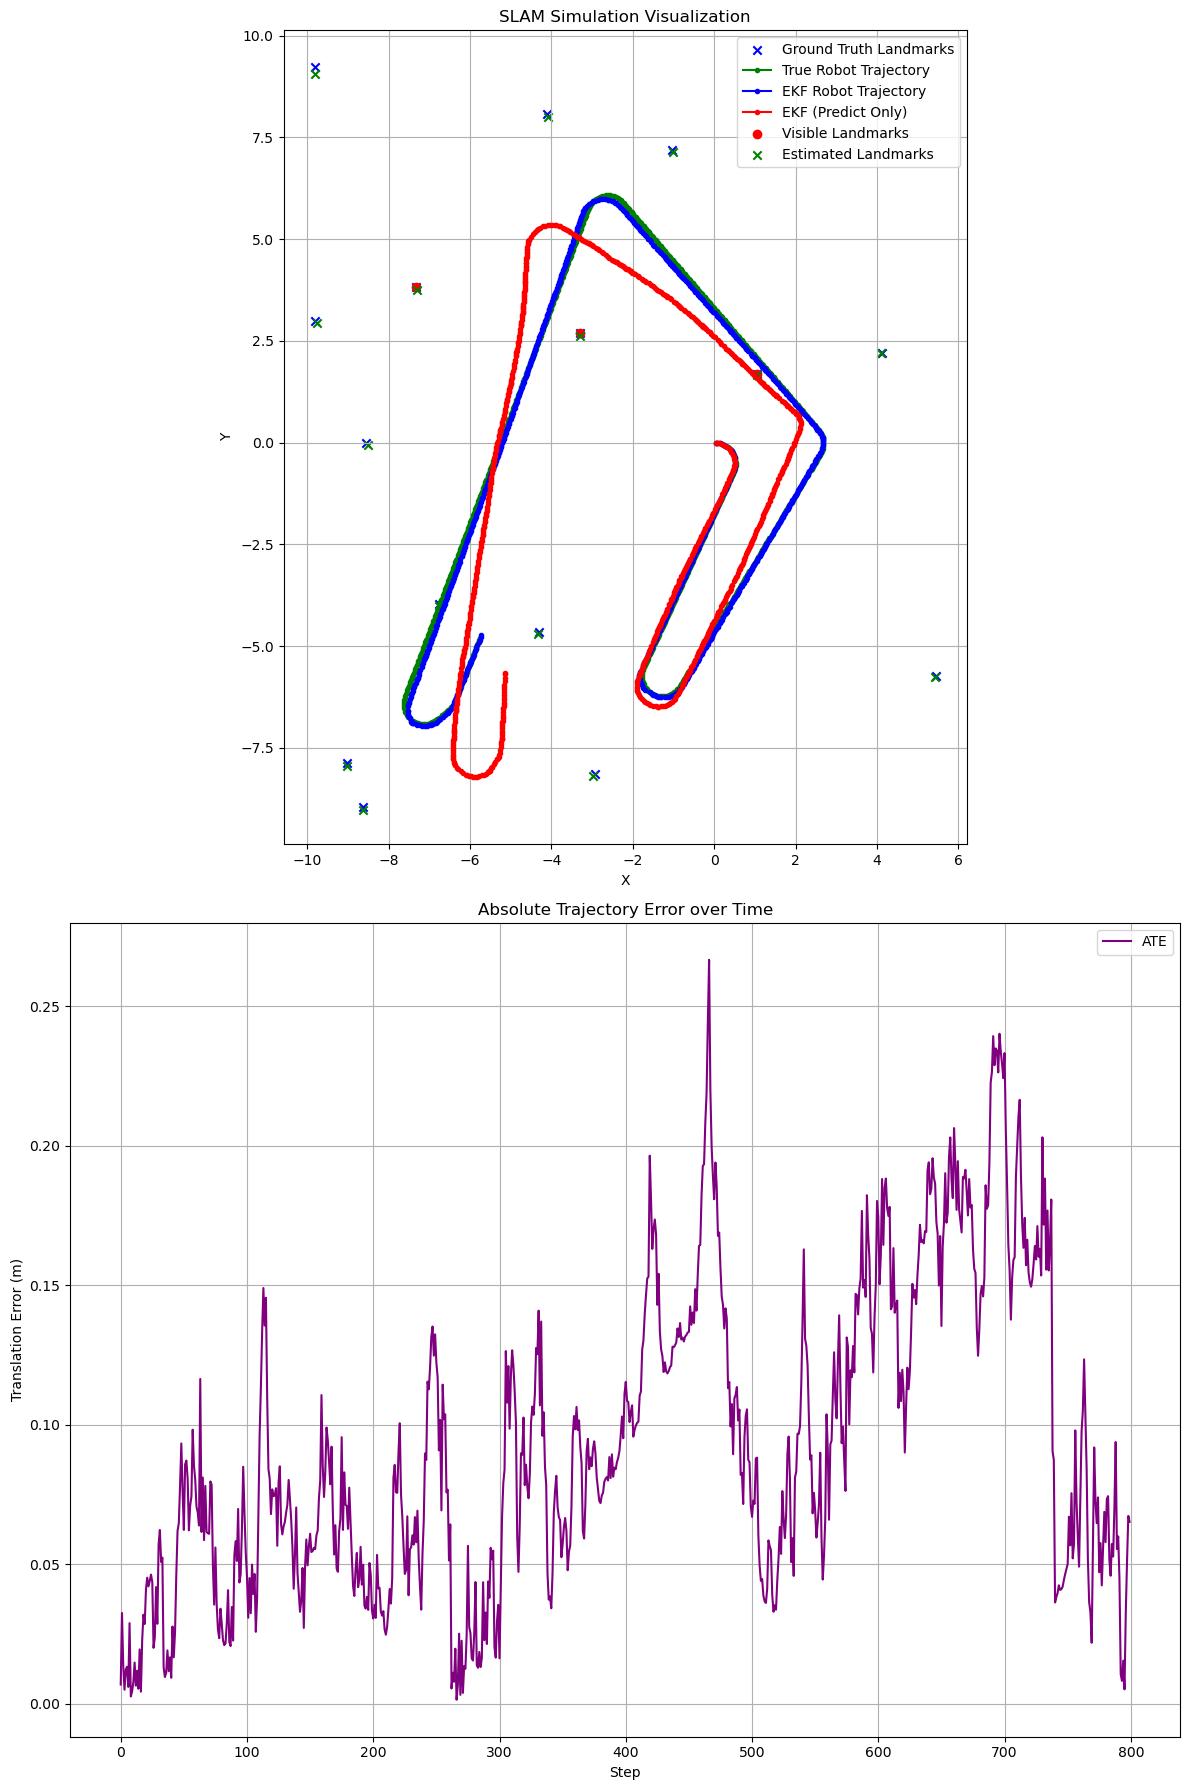

In [8]:
simulation = Simulation(
    grid_size=20,
    num_landmarks=15,
    measurement_noise_std=0.01,       #(meters, isometric)
    linear_odometry_noise_std=0.02,   #(meters, isometric)
    angular_odometry_noise_std=0.01,  #(radians)
    fov_range=10,
    fov_angle=np.pi/2,
    landmarks_file="lmks.txt",
    save_file=True)

ekf = ExtendedKalmanFilter()
ekf_predict = ExtendedKalmanFilter()
trajectory = []
visible_landmarks_history = []
ekf_trajectory_history = []
ekf_predict_trajectory_history = []
ekf_covariance_history = []
ekf_landmarks_history = []

ate_errors = []

num_steps = 800
ekf_update_interval = 2

for t in range(num_steps):
    control_measurement = simulation.step(t)
    true_pose = simulation.get_true_robot_pose()
    trajectory.append(true_pose)

    ekf.predict(control_measurement)
    ekf_predict.predict(control_measurement)

    measurements, visible = simulation.get_landmark_measurements(true_pose)
    visible_landmarks_history.append(visible)

    if t % ekf_update_interval == 0:
        ekf.update(measurements)
    ekf_landmarks_history.append(ekf.landmarks)

    ekf_trajectory_history.append(ekf.pose)
    ekf_covariance_history.append(ekf.pose_covariance)

    ekf_predict_trajectory_history.append(ekf_predict.pose)

    #calculate metric
    true_pose_se2 = se2(data=true_pose)
    estimated_pose_se2 = ekf.pose_as_se2()

    ate_error_se2 = true_pose_se2.inverse() * estimated_pose_se2
    #currently just x,y error
    ate_error = np.linalg.norm(ate_error_se2.matrix()[:2, 2])

    ate_errors.append(ate_error)


# Create two subplots: one for SLAM visualization, one for Error
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 18))

# convert estimate landmarks to dictionary form
landmarks = ekf.landmarks

landmarks_dict = {}
for label in ekf._landmark_index.keys():
  landmarks_dict[label] = ekf.landmark(label)

error_metric = calculateMapError(simulation, landmarks_dict)
print(f"Final Map error is {error_metric}")

# Visualize SLAM with trajectories and covariance
visualize_slam_animation(fig, ax1, simulation, as_animation=False,
                                trajectory=trajectory,
                                visible_landmarks_history=visible_landmarks_history,
                                ekf_trajectory_history=ekf_trajectory_history,
                                ekf_covariance_history=ekf_covariance_history,
                                ekf_landmarks_history= ekf_landmarks_history,
                                ekf_predict_trajectory_history=ekf_predict_trajectory_history
                         )

# Visualize ATE error over time
visualize_errors(fig, ax2, ate_errors)

plt.tight_layout()
plt.show()